
# 

#        WEBSCRAPE EBAY PRODUCT DATA  


#### This data below show a filter category of books that contain Business Intelligence in its title 

# 

In [ ]:
# Import all libraries required

import requests
import pandas as pd
from bs4 import BeautifulSoup
import matplotlib.pyplot as plt
import seaborn as sns
from prettytable import PrettyTable

In [ ]:
# Specify the URL of the Ebay item

url_pattern = 'https://www.ebay.com/sch/i.html?_from=R40&_trksid=p2334524.m570.l1313&_nkw=baby+toys&_sacat=267&_odkw=preschool+toys&_osacat=267'

In [ ]:
# create an empty list to store the scraped data
product_data = []

# iterate over the page numbers
for page_num in range(1, 11):   # scrape data from page 1 to 10
    print(f"Scraping page {page_num}...")
    # create the url for the current page
    url = url_pattern.format(page_num=page_num)

Scraping page 1...
Scraping page 2...
Scraping page 3...
Scraping page 4...
Scraping page 5...
Scraping page 6...
Scraping page 7...
Scraping page 8...
Scraping page 9...
Scraping page 10...


In [ ]:
#send a GET request to the URL and extract the HTML content

response = requests.get(url)
content = response.content

In [ ]:
#Use Beautiful Soup to parse the HTML content

soup = BeautifulSoup(content, 'html.parser')

In [ ]:
#Extract the product information needed
items = soup.find_all('div', {'class': 's-item__wrapper clearfix'})
    

for item in items:
    title = item.find('div', {'class': 's-item__title'}).text.strip()
    
    price_sold = float(item.find('span', {'class': 's-item__price'}).text.replace('$','').replace(',','').strip())
    shipping_cost = item.find('span', {'class': 's-item__shipping s-item__logisticsCost'})
    if shipping_cost:
        shipping_cost = shipping_cost.text.replace('+','').replace('$','').replace(',','').strip()
    else:
        shipping_cost = 0.0
    item_location = item.find('span', {'class': 's-item__location s-item__itemLocation'})
    if item_location:
        item_location = item_location.text.replace('from','').strip()
    else:
        item_location = ''
    item_seller = item.find('span', {'class':'s-item__seller-info'})
    if item_seller:
        item_seller = item_seller.text.strip()
    else:
        item_seller = ''
    link = item.find('a', {'class': 's-item__link'})['href']
    product_data.append([title, price_sold, shipping_cost, item_location, item_seller, link])
    
BabyToys = pd.DataFrame(product_data, columns=['Title', 'Price_sold', 'Shipping_cost', 'Item_location','Item_seller', 'Link'])
print(BabyToys.head())

ValueError: could not convert string to float: '1.27 to 3.82'

In [ ]:
#Display the first 2 rows of the BabyToys

BabyToys.head(5)

,Title,Price_sold,Shipping_cost,Item_location,Item_seller,Link
0,Shop on eBay,20.00,0.0,,,https://ebay.com/itm/123456?itmmeta=012DEW30YG...
1,Shop on eBay,20.00,0.0,,,https://ebay.com/itm/123456?itmmeta=012DEW30YG...
2,Baby's Toys (Babys World Ser),48.74,14.60 shipping,United States,"ontimebooks (29,938) 97.4%",https://www.ebay.com/itm/386677742328?_skw=bab...
3,Showa Retro baby toys #PCGL09,89.00,Free International Shipping,Japan,garage-kamakura (557) 97%,https://www.ebay.com/itm/315931515081?_skw=bab...
4,Samsung 100 Buttons Smart Pad Learning Korean ...,90.10,Free International Shipping,South Korea,buytokorea11 (420) 100%,https://www.ebay.com/itm/133123850925?_skw=bab...


In [ ]:
#To separate the Item_seller column into two columns, one for the seller name and one for the seller rating

BabyToys[['Seller_name','Seller_feedback', 'Seller_Rating%']] = BabyToys['Item_seller'].str.split(' ', expand=True)
BabyToys.head(5)

,Title,Price_sold,Shipping_cost,Item_location,Item_seller,Link,Seller_name,Seller_feedback,Seller_Rating%,Shipping_cost_value,Shipping_type
2,Baby's Toys (Babys World Ser),48.74,14.60 shipping,United States,"ontimebooks (29,938) 97.4%",https://www.ebay.com/itm/386677742328?_skw=bab...,ontimebooks,"(29,938)",97.4%,14.60,Paid shipping
3,Showa Retro baby toys #PCGL09,89.00,Free International Shipping,Japan,garage-kamakura (557) 97%,https://www.ebay.com/itm/315931515081?_skw=bab...,garage-kamakura,(557),97%,0.00,Free International shipping
4,Samsung 100 Buttons Smart Pad Learning Korean ...,90.10,Free International Shipping,South Korea,buytokorea11 (420) 100%,https://www.ebay.com/itm/133123850925?_skw=bab...,buytokorea11,(420),100%,0.00,Free International shipping
5,"TOYS TO MAKE Over 60 simple, educational toys ...",7.57,12.74 shipping,Australia,"linkmonk (8,891) 99.8%",https://www.ebay.com/itm/125249725708?_skw=bab...,linkmonk,"(8,891)",99.8%,12.74,Paid shipping
6,Crocheted Baby Toys,260.05,23.21 shipping,United States,"bluevasemarketplace (188,776) 99.5%",https://www.ebay.com/itm/126777551534?_skw=bab...,bluevasemarketplace,"(188,776)",99.5%,23.21,Paid shipping


In [ ]:
#Drop the first row column 

BabyToys = BabyToys.drop([0, 1], axis=0) #drop the first 2 rows

BabyToys.head(2)

In [ ]:
#check for null values

BabyToys.isnull().sum()

Title                  0
Price_sold             0
Shipping_cost          0
Item_location          0
Item_seller            0
Link                   0
Seller_name            0
Seller_feedback        0
Seller_Rating%         0
Shipping_cost_value    0
Shipping_type          0
dtype: int64

In [ ]:
#Remove the brackets from the 'Seller_feedback' column by calling the str.replace() 
BabyToys['Seller_feedback'] = BabyToys['Seller_feedback'].str.replace('[(),]', '', regex=True)


#Remove the Percentage % sign from the 'Seller_Rating%' column
BabyToys['Seller_Rating%'] = BabyToys['Seller_Rating%'].str.replace('%', '', regex=True)


#Convert the column datatype using the astype()

BabyToys['Seller_feedback'] = BabyToys['Seller_feedback'].astype(int)
BabyToys['Seller_Rating%'] = BabyToys['Seller_Rating%'].astype(float)
BabyToys.head(2)

,Title,Price_sold,Shipping_cost,Item_location,Item_seller,Link,Seller_name,Seller_feedback,Seller_Rating%,Shipping_cost_value,Shipping_type
2,Baby's Toys (Babys World Ser),48.74,14.60 shipping,United States,"ontimebooks (29,938) 97.4%",https://www.ebay.com/itm/386677742328?_skw=bab...,ontimebooks,29938,97.4,14.6,Paid shipping
3,Showa Retro baby toys #PCGL09,89.00,Free International Shipping,Japan,garage-kamakura (557) 97%,https://www.ebay.com/itm/315931515081?_skw=bab...,garage-kamakura,557,97.0,0.0,Free International shipping


In [ ]:
#Check for null values

BabyToys.isnull().sum()

Title                  0
Price_sold             0
Shipping_cost          0
Item_location          0
Item_seller            0
Link                   0
Seller_name            0
Seller_feedback        0
Seller_Rating%         0
Shipping_cost_value    0
Shipping_type          0
dtype: int64

In [ ]:
#Check for info

BabyToys.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 76 entries, 2 to 77
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Title                76 non-null     object 
 1   Price_sold           76 non-null     float64
 2   Shipping_cost        76 non-null     object 
 3   Item_location        76 non-null     object 
 4   Item_seller          76 non-null     object 
 5   Link                 76 non-null     object 
 6   Seller_name          76 non-null     object 
 7   Seller_feedback      76 non-null     int64  
 8   Seller_Rating%       76 non-null     float64
 9   Shipping_cost_value  76 non-null     float64
 10  Shipping_type        76 non-null     object 
dtypes: float64(3), int64(1), object(7)
memory usage: 6.7+ KB


In [ ]:
BabyToys.head(45)

,Title,Price_sold,Shipping_cost,Item_location,Item_seller,Link,Seller_name,Seller_feedback,Seller_Rating%,Shipping_cost_value,Shipping_type
2,Baby's Toys (Babys World Ser),48.74,14.60 shipping,United States,"ontimebooks (29,938) 97.4%",https://www.ebay.com/itm/386677742328?_skw=bab...,ontimebooks,29938,97.4,14.60,Paid shipping
3,Showa Retro baby toys #PCGL09,89.00,Free International Shipping,Japan,garage-kamakura (557) 97%,https://www.ebay.com/itm/315931515081?_skw=bab...,garage-kamakura,557,97.0,0.00,Free International shipping
4,Samsung 100 Buttons Smart Pad Learning Korean ...,90.10,Free International Shipping,South Korea,buytokorea11 (420) 100%,https://www.ebay.com/itm/133123850925?_skw=bab...,buytokorea11,420,100.0,0.00,Free International shipping
5,"TOYS TO MAKE Over 60 simple, educational toys ...",7.57,12.74 shipping,Australia,"linkmonk (8,891) 99.8%",https://www.ebay.com/itm/125249725708?_skw=bab...,linkmonk,8891,99.8,12.74,Paid shipping
6,Crocheted Baby Toys,260.05,23.21 shipping,United States,"bluevasemarketplace (188,776) 99.5%",https://www.ebay.com/itm/126777551534?_skw=bab...,bluevasemarketplace,188776,99.5,23.21,Paid shipping
7,Quick Knit Baby Toys: 20 Knitting Patterns for...,16.42,12.50 shipping,United States,"bargainbookstores (1,113,748) 99.3%",https://www.ebay.com/itm/387618105980?_skw=bab...,bargainbookstores,1113748,99.3,12.50,Paid shipping
8,Quick Knit Baby Toys: 20 Beginner-Friendly Pat...,18.35,51.72 shipping,Australia,"the_nile (1,229,344) 98.8%",https://www.ebay.com/itm/146143625904?_skw=bab...,the_nile,1229344,98.8,51.72,Paid shipping
9,"Baby Bop's Toys by Kearns & O'Brien 1993, Min...",9.99,16.43 shipping,United States,mtnest17 (502) 100%,https://www.ebay.com/itm/186634123379?_skw=bab...,mtnest17,502,100.0,16.43,Paid shipping
10,New ListingKate DiCamillo SIGNED BOOK The Pup...,35.00,23.04 shipping,United States,"iopsy (1,005) 100%",https://www.ebay.com/itm/205163568604?_skw=bab...,iopsy,1005,100.0,23.04,Paid shipping
11,New ListingWorld of Eric Carle Me Reader Jr & ...,20.00,29.81 shipping,United States,northern_flipper (48) 100%,https://www.ebay.com/itm/356372090158?_skw=bab...,northern_flipper,48,100.0,29.81,Paid shipping


In [ ]:
#create new columns for shipping cost value and shipping type from 'Shipping_cost'column
BabyToys[['Shipping_cost_value', 'Shipping_type']] = BabyToys['Shipping_cost'].str.extract('([\d\.]+)\s*([a-zA-Z\s]+)', expand=True)

#show the updated dataframe
BabyToys.head(2)

,Title,Price_sold,Shipping_cost,Item_location,Item_seller,Link,Seller_name,Seller_feedback,Seller_Rating%,Shipping_cost_value,Shipping_type
2,Baby's Toys (Babys World Ser),48.74,14.60 shipping,United States,"ontimebooks (29,938) 97.4%",https://www.ebay.com/itm/386677742328?_skw=bab...,ontimebooks,29938,97.4,14.60,shipping
3,Showa Retro baby toys #PCGL09,89.00,Free International Shipping,Japan,garage-kamakura (557) 97%,https://www.ebay.com/itm/315931515081?_skw=bab...,garage-kamakura,557,97.0,NaN,NaN


In [ ]:
#add "paid" in front of "shipping" in the Shipping_type column
BabyToys['Shipping_type'] = 'Paid ' + BabyToys['Shipping_type'].str.replace('shipping', 'shipping', regex=True)


#Fill the NaN values in the Shipping_type column with 'Free International shipping'
BabyToys['Shipping_type'] = BabyToys['Shipping_type'].fillna('Free International shipping')


#Fill the NaN values in the Shipping_type column with 'Free International shipping'
BabyToys['Shipping_cost_value'] = BabyToys['Shipping_cost_value'].fillna(0)


#Convert data type to float
BabyToys['Shipping_cost_value'] = BabyToys['Shipping_cost_value'].astype(float)


BabyToys.head(2)

,Title,Price_sold,Shipping_cost,Item_location,Item_seller,Link,Seller_name,Seller_feedback,Seller_Rating%,Shipping_cost_value,Shipping_type
2,Baby's Toys (Babys World Ser),48.74,14.60 shipping,United States,"ontimebooks (29,938) 97.4%",https://www.ebay.com/itm/386677742328?_skw=bab...,ontimebooks,29938,97.4,14.6,Paid shipping
3,Showa Retro baby toys #PCGL09,89.00,Free International Shipping,Japan,garage-kamakura (557) 97%,https://www.ebay.com/itm/315931515081?_skw=bab...,garage-kamakura,557,97.0,0.0,Free International shipping


In [ ]:
BabyToys.tail(10)

,Title,Price_sold,Shipping_cost,Item_location,Item_seller,Link,Seller_name,Seller_feedback,Seller_Rating%,Shipping_cost_value,Shipping_type
68,The Dragons Cold - Hardcover By John Talbot - ...,5.30,10.50 shipping,United States,"second.sale (3,746,294) 98.4%",https://www.ebay.com/itm/276655322347?_skw=bab...,second.sale,3746294,98.4,10.50,Paid shipping
69,GC Discovery Tos My First Book of Time Hardcov...,6.95,19.88 shipping,United States,"julie04181975 (5,611) 100%",https://www.ebay.com/itm/204998289981?_skw=bab...,julie04181975,5611,100.0,19.88,Paid shipping
70,Spot 7 Toys - Hardcover By KIDSLABEL - GOOD,5.16,10.50 shipping,United States,"second.sale (3,746,294) 98.4%",https://www.ebay.com/itm/266772949318?_skw=bab...,second.sale,3746294,98.4,10.50,Paid shipping
71,Baby's First Book (Little Golden Book) - Hardc...,4.00,10.50 shipping,United States,"second.sale (3,746,294) 98.4%",https://www.ebay.com/itm/256448014013?_skw=bab...,second.sale,3746294,98.4,10.50,Paid shipping
72,"Bitty Baby at the Ballet , Larson, Kirby",4.29,14.42 shipping,United States,"gently.loved.books (110,251) 99.4%",https://www.ebay.com/itm/395465832480?_skw=bab...,gently.loved.books,110251,99.4,14.42,Paid shipping
73,hahaland Baby Book Baby Toys Jungle Sensory Bo...,24.51,8.13 shipping,Germany,poke-dav (32) 0%,https://www.ebay.com/itm/316030213258?_skw=bab...,poke-dav,32,0.0,8.13,Paid shipping
74,Random House 2004 Dr Seuss Circus McGurkus Plu...,8.99,15.54 shipping,United States,bbsales365 (265) 100%,https://www.ebay.com/itm/395695547241?_skw=bab...,bbsales365,265,100.0,15.54,Paid shipping
75,Realistic Insect RC Stag Beetle Toy Remote-Con...,48.00,12.83 shipping,Japan,mystical-japan-treasures (412) 100%,https://www.ebay.com/itm/286184224948?_skw=bab...,mystical-japan-treasures,412,100.0,12.83,Paid shipping
76,Smart Toys: For Babies from Birth to Two by Bu...,8.24,9.25 shipping,United States,"thrift.books (3,762,963) 99%",https://www.ebay.com/itm/146261584577?_skw=bab...,thrift.books,3762963,99.0,9.25,Paid shipping
77,DITTY BIRD Baby Sound Toy: Our Learning Songs ...,18.34,10.50 shipping,United States,"second.sale (3,746,294) 98.4%",https://www.ebay.com/itm/266774875123?_skw=bab...,second.sale,3746294,98.4,10.50,Paid shipping


In [ ]:
#Check for info

BabyToys.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 76 entries, 2 to 77
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Title                76 non-null     object 
 1   Price_sold           76 non-null     float64
 2   Shipping_cost        76 non-null     object 
 3   Item_location        76 non-null     object 
 4   Item_seller          76 non-null     object 
 5   Link                 76 non-null     object 
 6   Seller_name          76 non-null     object 
 7   Seller_feedback      76 non-null     int64  
 8   Seller_Rating%       76 non-null     float64
 9   Shipping_cost_value  76 non-null     float64
 10  Shipping_type        76 non-null     object 
dtypes: float64(3), int64(1), object(7)
memory usage: 6.7+ KB


# 

# 

## Data Analysis 

What is the: 
* Average price of books
* Average shipping cost
* Seller feedback and rating
* Shipping type
* Item location
* Price vs. shipping cost
* Top sellers
* Price distribution by seller

In [ ]:
BabyToys.describe()

,Price_sold,Seller_feedback,Seller_Rating%,Shipping_cost_value
count,76.000000,7.600000e+01,76.000000,76.000000
mean,22.903421,7.845956e+05,96.003947,14.160921
std,38.899763,1.465702e+06,16.887158,9.544256
min,1.000000,0.000000e+00,0.000000,0.000000
25%,5.510000,6.272500e+02,98.700000,9.437500
50%,9.950000,2.655500e+03,99.500000,12.785000
75%,18.342500,3.299340e+05,100.000000,19.745000
max,260.050000,3.762963e+06,100.000000,51.720000



* The Average price of BIbooks on Ebay is 21.14
* The Average shipping cost of BIbooks on Ebay is  27.47

* The Minimum price of BIbooks on Ebay is 2
* The minimum shipping cost of BIbooks on Ebay is 0

* The Maximum price of of BIbooks on Ebay is 130.28
* The Maximum shipping cost of BIbooks on Ebay is 202.23


# 

In [ ]:
BabyToys.nunique()

Title                  76
Price_sold             69
Shipping_cost          59
Item_location           8
Item_seller            60
Link                   76
Seller_name            60
Seller_feedback        60
Seller_Rating%         19
Shipping_cost_value    59
Shipping_type           3
dtype: int64

In [ ]:
# Filter numeric columns
numeric_data = BabyToys.select_dtypes(include=['float64', 'int64'])

# Compute correlation
correlation_matrix = numeric_data.corr()

# Display the correlation matrix
print(correlation_matrix)

                     Price_sold  Seller_feedback  Seller_Rating%  \
Price_sold             1.000000        -0.210335       -0.110459   
Seller_feedback       -0.210335         1.000000        0.088510   
Seller_Rating%        -0.110459         0.088510        1.000000   
Shipping_cost_value    0.025132        -0.302238        0.085287   

                     Shipping_cost_value  
Price_sold                      0.025132  
Seller_feedback                -0.302238  
Seller_Rating%                  0.085287  
Shipping_cost_value             1.000000  


# 



* The correlation coefficient between Price_sold and Shipping_cost_value is 0.325289, this indicates a weak positive correlation, which means that there is some tendency for books with higher prices to have higher shipping costs.


* The correlation coefficient between Price_sold and Seller_feedback is -0.236621, this indicates a negative correlation, the negative correlation coefficient suggests that as the seller feedback rating increases, the price of the book tends to decrease. 


* The correlation coefficient between Price_sold and Seller_Rating% is -0.034804, this indicates no significant correlation between them.


# 

In [ ]:
#Number of books by location
BabyToys['Item_location'].value_counts()

Item_location
United States     59
Japan              5
South Korea        3
Australia          3
China              3
Canada             1
United Kingdom     1
Germany            1
Name: count, dtype: int64

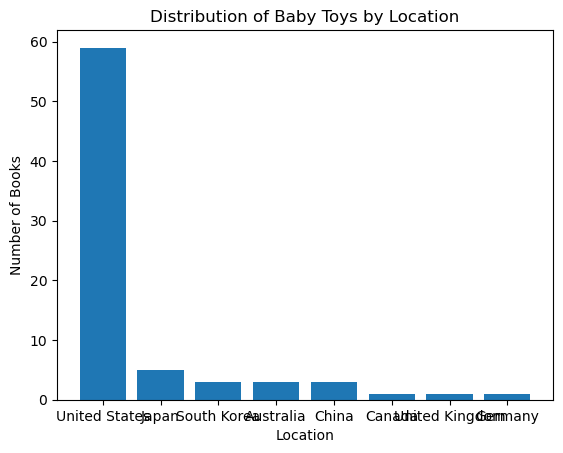

In [ ]:
#number of books by location
BabyToys_location = BabyToys['Item_location'].value_counts()


plt.bar(BabyToys_location.index, BabyToys_location.values)


plt.title('Distribution of Baby Toys by Location')
plt.xlabel('Location')
plt.ylabel('Number of Books')


plt.show()


# 

# 

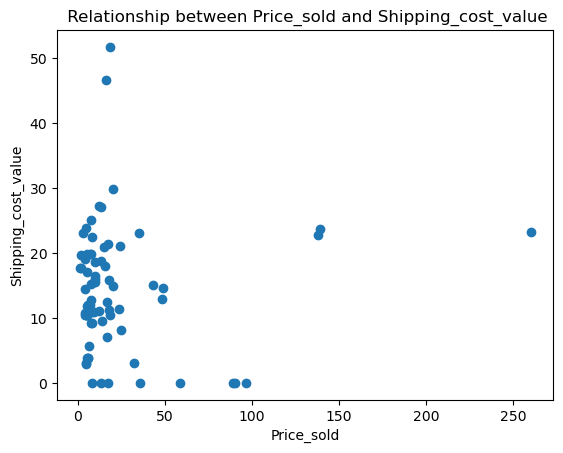

In [ ]:
#Relationship between 'Price_sold' and 'Shipping_cost_value'

plt.scatter(x=BabyToys['Price_sold'], y=BabyToys['Shipping_cost_value'])

plt.title(' Relationship between Price_sold and Shipping_cost_value')
plt.xlabel('Price_sold')
plt.ylabel('Shipping_cost_value')


plt.show()


* The scattterplot also this indicates a weak positive correlation, which confirms that there is some tendency for books with higher prices to have higher shipping costs.

# 

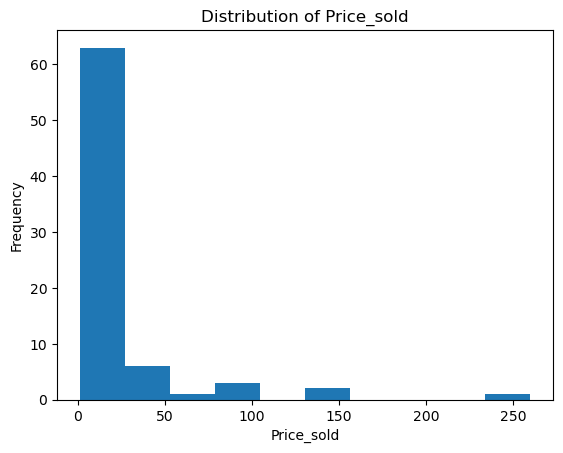

In [ ]:
#Distribution of Price_sold

plt.hist(BabyToys['Price_sold'], bins=10)

plt.title('Distribution of Price_sold')
plt.xlabel('Price_sold')
plt.ylabel('Frequency')
plt.show()

* Most BIbooks on EBAY are sold within the range of 2 Dollars  to 20 dollars

# 

In [ ]:
#Count of shipping type
BabyToys['Shipping_type'].value_counts()

Shipping_type
Paid shipping                  67
Free International shipping     8
Paid shipping estimate          1
Name: count, dtype: int64

In [ ]:
# total shipping cost of shipping type

BabyToys.groupby('Shipping_type')['Shipping_cost_value'].sum()

Shipping_type
Free International shipping       0.00
Paid shipping                  1052.38
Paid shipping estimate           23.85
Name: Shipping_cost_value, dtype: float64

In [ ]:
# max shipping cost of shipping type

BabyToys.groupby('Shipping_type')['Shipping_cost_value'].max()

Shipping_type
Free International shipping     0.00
Paid shipping                  51.72
Paid shipping estimate         23.85
Name: Shipping_cost_value, dtype: float64

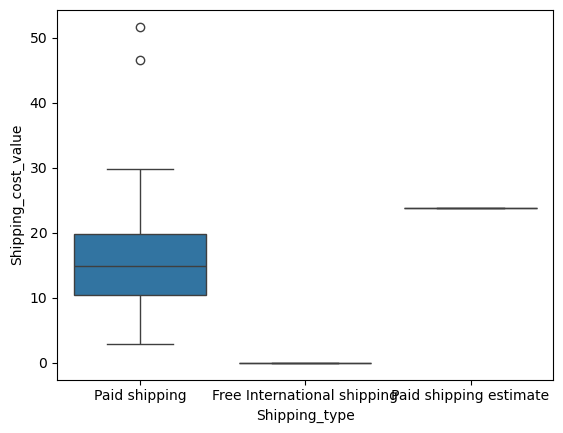

In [ ]:
#relationship between Shipping_cost_value and Shipping_type 




sns.boxplot(x='Shipping_type', y='Shipping_cost_value', data=BabyToys)
plt.show()


# 

67 of the BI books has Paid shipping, which comes to a total cost of $1725.17, and the highest shipping cost for a book is 44.16 
   

# 

In [ ]:
#find the top 10 Seller_name with the highest Seller_feedback

BabyToys.groupby('Seller_name')['Seller_feedback'].max().nlargest(10)

Seller_name
thrift.books            3762963
second.sale             3746294
decluttr_store          3672494
betterworldbooks        2682900
the_nile                1229344
bargainbookstores       1113748
grandeagleretail         933915
betterworldbookswest     329934
bluevasemarketplace      188776
gently.loved.books       110251
Name: Seller_feedback, dtype: int64

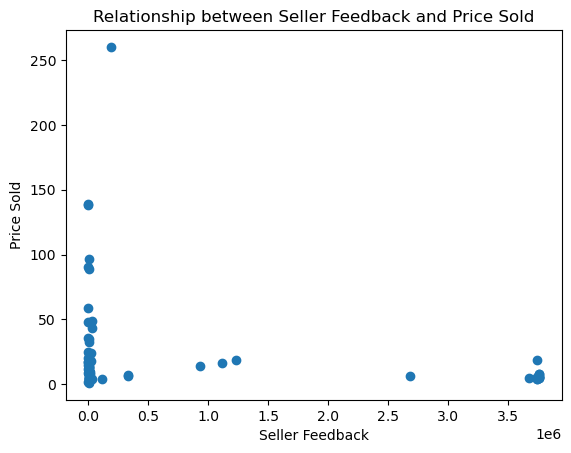

In [ ]:
# Create a scatter plot
plt.scatter(BabyToys['Seller_feedback'], BabyToys['Price_sold'])

# Add chart labels
plt.title('Relationship between Seller Feedback and Price Sold')
plt.xlabel('Seller Feedback')
plt.ylabel('Price Sold')

# Display the chart
plt.show()


# 

In [ ]:
# top 10 most expensive book by title
top_books = BabyToys.groupby('Title')['Price_sold'].max().nlargest(10)


table = PrettyTable()
table.field_names = ["Title", "Price Sold"]


for Title, price_sold in zip(top_books.index, top_books.values):
    table.add_row([Title, price_sold])


print(table)


+-----------------------------------------------------------------------------+------------+
|                                    Title                                    | Price Sold |
+-----------------------------------------------------------------------------+------------+
|                             Crocheted Baby Toys                             |   260.05   |
|   Your Baby Can Read Deluxe Kit NEW ENGLISH Reading System DVD BOOK CARDS   |   139.0    |
|                                 Monster High                                |   137.99   |
|                              baby toys #YN5SVR                              |   96.63    |
| Samsung 100 Buttons Smart Pad Learning Korean Play Toy For Baby Infant Kids |    90.1    |
|                        Showa Retro baby toys #PCGL09                        |    89.0    |
|      Pinkfong Pop-up Smartphone Melody Toy Korean Version For Baby&Kids     |   58.61    |
|                        Baby's Toys (Babys World Ser)                

# 

In [ ]:

# Save the DataFrame to a CSV file
output_file = '/Users/hannah/Documents/eBay scraper/BabyToys.csv'
BabyToys.to_csv(output_file, index=False)
print(f"Data saved to {output_file}")

# 